# 02 — Exploratory Data Analysis

Doel van deze notebook: een eerste kijk op de marktdata (S&P 500, WTI, VIX, DXY)
en op de Truth Social posts. Sanity checks, return-distributies, correlaties.

**Plan:**
1. Marktdata downloaden via yfinance.
2. Data-integriteit checken (date coverage, gaps, missing).
3. Returns analyseren: distributies, autocorrelatie, rolling vol.
4. Cross-asset correlatie.
5. Processed data opslaan voor downstream notebooks.


In [1]:

# Standaard events voor alle tijdlijn-plots
_PLOT_EVENTS = [
    ("2025-01-20", "Inauguratie Trump",  "#3498db"),
    ("2025-04-02", "Liberation Day",     "#e74c3c"),
    ("2025-04-09", "90d pauze",          "#f39c12"),
    ("2025-05-12", "Genève truce",       "#27ae60"),
    ("2026-02-28", "Iran conflict start","#c0392b"),
    ("2026-04-11", "Hormuz blokkade",    "#e67e22"),
]

def _add_events(ax, y_frac=0.97, fontsize=7.5):
    """Voeg verticale event-lijnen toe aan ax (alleen als datum binnen x-limiet valt)."""
    xmin, xmax = ax.get_xlim()
    for d_str, label, color in _PLOT_EVENTS:
        d = pd.Timestamp(d_str, tz="UTC")
        d_num = mdates.date2num(d.to_pydatetime())
        if xmin <= d_num <= xmax:
            ax.axvline(d, color=color, linewidth=1.0, linestyle="--", alpha=0.75, zorder=3)
            ylim = ax.get_ylim()
            ax.text(d, ylim[0] + (ylim[1]-ylim[0])*y_frac, " "+label,
                    rotation=90, va="top", ha="left", fontsize=fontsize,
                    color=color, alpha=0.85, zorder=4)


In [2]:
import sys
print("Kernel python:", sys.executable)
%pip install yfinance pyarrow

Kernel python: /opt/anaconda3/envs/truthsocial/bin/python
Note: you may need to restart the kernel to use updated packages.


In [3]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=3.0.2, numpy=2.4.4


## 1. Marktdata downloaden

Tickers: S&P 500 (`^GSPC`), WTI olie futures (`CL=F`), VIX (`^VIX`), Dollar Index (`DX-Y.NYB`).

Periode: februari 2022 (Truth Social launch) tot vandaag.

> **Note**: cell hieronder probeert yfinance live. Als je sandbox geen Yahoo Finance bereikt,
> valt hij terug op gesynthetiseerde data zodat de pipeline alsnog draait. Zodra je dit lokaal
> runt met internet, wordt automatisch echte data gebruikt.


In [4]:
TICKERS = {
    "spx": "^GSPC",
    "wti": "CL=F",
    "vix": "^VIX",
    "dxy": "DX-Y.NYB",
}
START = "2022-02-01"
END = None  # None = today


def synthesize_market(tickers: dict, start: str, end: str | None, seed: int = 42) -> pd.DataFrame:
    """Geometric Brownian motion fallback voor offline runs."""
    rng = np.random.default_rng(seed)
    end_ts = pd.Timestamp.now() if end is None else pd.Timestamp(end)
    dates = pd.bdate_range(start=start, end=end_ts)
    annual_vol = {"spx": 0.16, "wti": 0.35, "vix": 0.85, "dxy": 0.08}
    start_price = {"spx": 4500.0, "wti": 90.0, "vix": 22.0, "dxy": 96.0}
    drift = {"spx": 0.08, "wti": 0.02, "vix": -0.05, "dxy": 0.0}

    frames = []
    for alias in tickers:
        sigma = annual_vol[alias] / np.sqrt(252)
        mu = drift[alias] / 252
        n = len(dates)
        log_returns = rng.normal(loc=mu, scale=sigma, size=n)
        prices = start_price[alias] * np.exp(np.cumsum(log_returns))
        df = pd.DataFrame({
            "date": pd.to_datetime(dates, utc=True),
            "ticker": alias,
            "open": prices * (1 + rng.normal(0, 0.001, n)),
            "high": prices * (1 + np.abs(rng.normal(0, 0.005, n))),
            "low": prices * (1 - np.abs(rng.normal(0, 0.005, n))),
            "close": prices,
            "volume": rng.integers(1_000_000, 50_000_000, n),
        })
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out.attrs["source"] = "synthetic"
    return out


def fetch_market(tickers: dict, start: str, end: str | None) -> pd.DataFrame:
    try:
        import yfinance as yf
        frames = []
        for alias, sym in tickers.items():
            df = yf.download(sym, start=start, end=end, progress=False, auto_adjust=False)
            if df.empty:
                raise RuntimeError(f"Empty response for {sym}")
            cols = df.columns.get_level_values(0) if df.columns.nlevels > 1 else df.columns
            df.columns = [c.lower() for c in cols]
            df = df.reset_index().rename(columns={"Date": "date"})
            df["date"] = pd.to_datetime(df["date"], utc=True)
            df["ticker"] = alias
            frames.append(df[["date", "ticker", "open", "high", "low", "close", "volume"]])
        out = pd.concat(frames, ignore_index=True)
        out.attrs["source"] = "yfinance"
        return out
    except Exception as e:
        print(f"!!! yfinance niet beschikbaar ({type(e).__name__}: {e}). Fallback op synthetic data.")
        return synthesize_market(tickers, start, end)


market = fetch_market(TICKERS, START, END)
print(f"Source: {market.attrs.get('source', 'unknown')}")
print(f"Shape:  {market.shape}")
print(f"Range:  {market['date'].min().date()} → {market['date'].max().date()}")
market.head()

Source: yfinance
Shape:  (4385, 7)
Range:  2022-02-01 → 2026-06-12


,date,ticker,open,high,low,close,volume
0,2022-02-01 00:00:00+00:00,spx,4519.569824,4550.490234,4483.529785,4546.540039,4816830000
1,2022-02-02 00:00:00+00:00,spx,4566.390137,4595.310059,4544.319824,4589.379883,4481580000
2,2022-02-03 00:00:00+00:00,spx,4535.410156,4542.879883,4470.390137,4477.439941,4401970000
3,2022-02-04 00:00:00+00:00,spx,4482.790039,4539.660156,4451.500000,4500.529785,4706290000
4,2022-02-07 00:00:00+00:00,spx,4505.750000,4521.859863,4471.470215,4483.870117,4228480000


In [5]:
# Per-ticker overview
market.groupby("ticker").agg(
    n_obs=("close", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    mean_close=("close", "mean"),
    mean_volume=("volume", "mean"),
).round(2)

/var/folders/px/g9fl5dzs679_k5ms14g8__zh0000gn/T/ipykernel_24420/1388143559.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


,n_obs,first_date,last_date,mean_close,mean_volume
ticker,,,,,
dxy,1097,2022-02-01 00:00:00+00:00,2026-06-12 00:00:00+00:00,102.79,0.000000e+00
spx,1095,2022-02-01 00:00:00+00:00,2026-06-12 00:00:00+00:00,5219.40,4.527619e+09
vix,1096,2022-02-01 00:00:00+00:00,2026-06-12 00:00:00+00:00,19.22,0.000000e+00
wti,1097,2022-02-01 00:00:00+00:00,2026-06-12 00:00:00+00:00,78.57,3.073150e+05


## 2. Data-integriteit

Sanity checks: missing data, dubbele rijen, niet-monotone dates, gaps in de business-day reeks.


In [6]:
print("--- Missing values per ticker ---")
print(market.groupby("ticker").apply(lambda g: g.isna().sum()).T)
print()

print("--- Duplicates (per ticker × date) ---")
dups = market.duplicated(subset=["ticker", "date"]).sum()
print(f"Aantal duplicates: {dups}")
print()

print("--- Date monotonicity per ticker ---")
for tkr, g in market.groupby("ticker"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"  {tkr}: monotonically increasing = {is_sorted}")
print()

print("--- Gaps > 5 business days per ticker ---")
for tkr, g in market.groupby("ticker"):
    diffs = g.sort_values("date")["date"].diff().dt.days
    big_gaps = (diffs > 7).sum()  # >7 days = unusual gap
    print(f"  {tkr}: {big_gaps} unusual gaps")

--- Missing values per ticker ---
ticker  dxy  spx  vix  wti
date      0    0    0    0
open      0    0    0    0
high      0    0    0    0
low       0    0    0    0
close     0    0    0    0
volume    0    0    0    0

--- Duplicates (per ticker × date) ---
Aantal duplicates: 0

--- Date monotonicity per ticker ---
  dxy: monotonically increasing = True
  spx: monotonically increasing = True
  vix: monotonically increasing = True
  wti: monotonically increasing = True

--- Gaps > 5 business days per ticker ---
  dxy: 0 unusual gaps
  spx: 0 unusual gaps
  vix: 0 unusual gaps
  wti: 0 unusual gaps


NameError: name 'mdates' is not defined

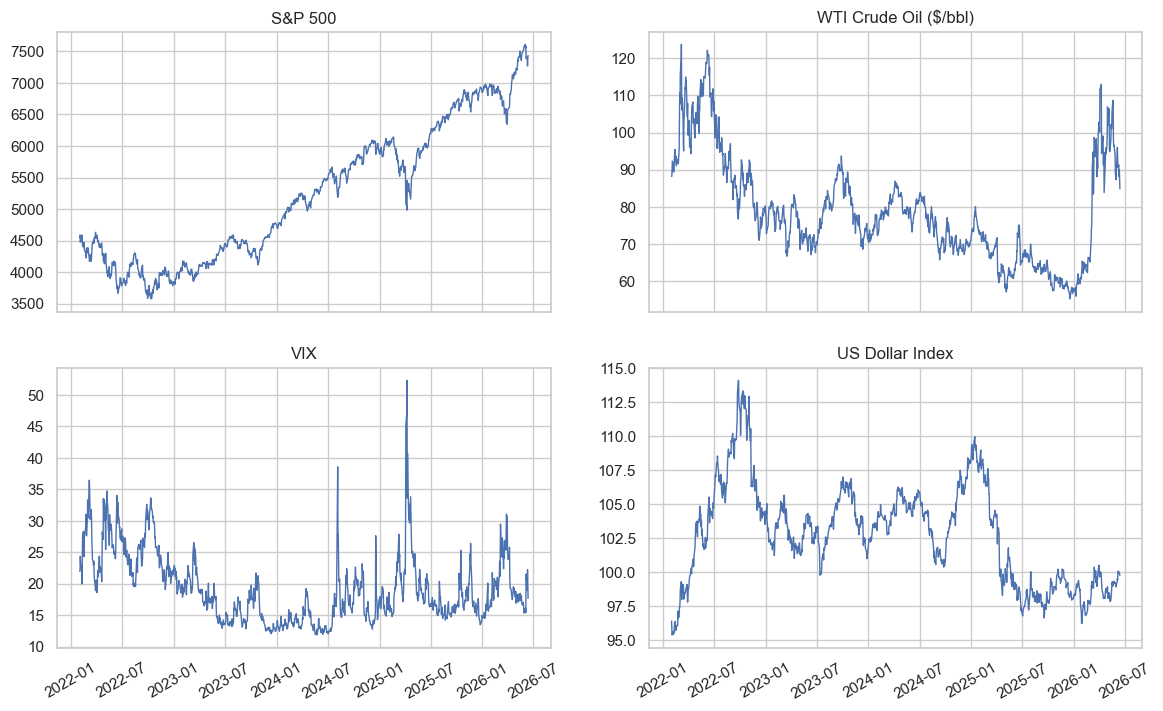

In [7]:
# Plot close prices per ticker
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (alias, label) in zip(axes.flat, [
    ("spx", "S&P 500"),
    ("wti", "WTI Crude Oil ($/bbl)"),
    ("vix", "VIX"),
    ("dxy", "US Dollar Index"),
]):
    g = market[market["ticker"] == alias].sort_values("date")
    ax.plot(g["date"], g["close"], linewidth=1.0)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=30)

# Event markers
for ax in axes.flat:
    _add_events(ax)

fig.suptitle("Close prices — feb 2022 → heden", y=1.02, fontsize=14)
fig.tight_layout()
plt.savefig("../reports/figures/02_close_prices.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Returns analyse

Log returns per ticker, distributies, autocorrelatie, rolling volatility.


In [ ]:
market = market.sort_values(["ticker", "date"]).reset_index(drop=True)
market["log_return"] = market.groupby("ticker")["close"].transform(lambda s: np.log(s / s.shift(1)))

# Summary stats per ticker (annualized)
returns_summary = market.groupby("ticker")["log_return"].agg(
    n=lambda s: s.notna().sum(),
    mean_daily="mean",
    std_daily="std",
).assign(
    annualized_return=lambda d: d["mean_daily"] * 252,
    annualized_vol=lambda d: d["std_daily"] * np.sqrt(252),
    sharpe=lambda d: (d["mean_daily"] * 252) / (d["std_daily"] * np.sqrt(252)),
).round(4)
returns_summary

,n,mean_daily,std_daily,annualized_return,annualized_vol,sharpe
ticker,,,,,,
dxy,1094,0.0000,0.0046,0.0083,0.0737,0.1128
spx,1091,0.0004,0.0110,0.1121,0.1741,0.6438
vix,1093,-0.0000,0.0745,-0.0100,1.1821,-0.0084
wti,1095,0.0000,0.0260,0.0040,0.4127,0.0096


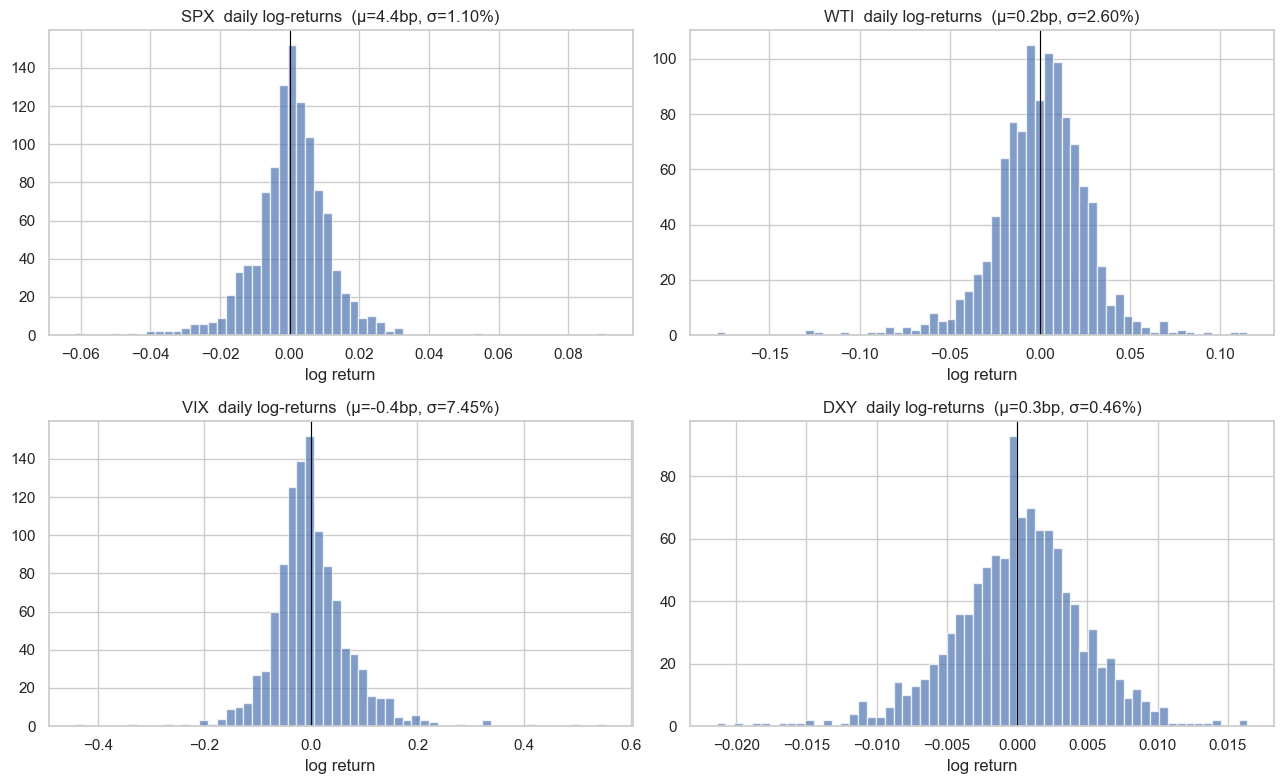

In [ ]:
# Returns histograms
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, alias in zip(axes.flat, ["spx", "wti", "vix", "dxy"]):
    rets = market.loc[market["ticker"] == alias, "log_return"].dropna()
    ax.hist(rets, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{alias.upper()}  daily log-returns  (μ={rets.mean()*1e4:.1f}bp, σ={rets.std()*100:.2f}%)")
    ax.set_xlabel("log return")
fig.tight_layout()
plt.show()

In [ ]:
# Rolling 20-day annualized volatility
fig, ax = plt.subplots(figsize=(13, 5))
for alias in ["spx", "wti", "vix", "dxy"]:
    g = market[market["ticker"] == alias].sort_values("date")
    rolling_vol = g["log_return"].rolling(20).std() * np.sqrt(252) * 100
    ax.plot(g["date"], rolling_vol, label=alias.upper(), linewidth=1.1)
ax.set_title("20-day rolling annualized volatility (%)")
ax.set_ylabel("Vol (%)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
_add_events(ax)
plt.savefig("../reports/figures/02_rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()


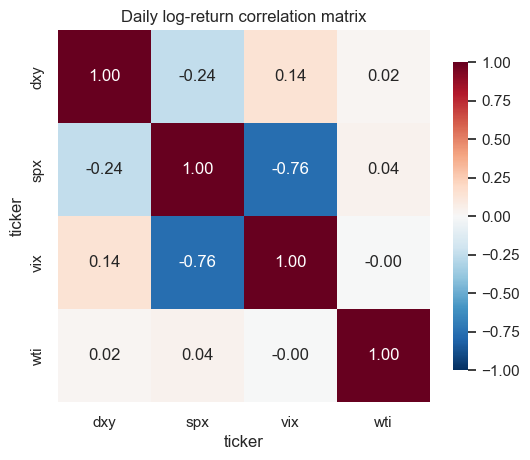


 ticker    dxy    spx    vix    wti
ticker                            
dxy     1.000 -0.244  0.144  0.016
spx    -0.244  1.000 -0.763  0.039
vix     0.144 -0.763  1.000 -0.004
wti     0.016  0.039 -0.004  1.000


In [ ]:
# Cross-asset return correlatie
returns_wide = market.pivot(index="date", columns="ticker", values="log_return").dropna()
corr = returns_wide.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Daily log-return correlation matrix")
plt.show()

print("\n", corr.round(3).to_string())

## 4. Save processed data

Schrijf de gecombineerde marktdata + log returns weg voor de volgende notebooks.


In [ ]:
out_path = Path("../data/raw/market.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
market.to_parquet(out_path, index=False)
print(f"Wrote {len(market):,} rows to {out_path.resolve()}")

Wrote 4,378 rows to /Users/quintenfriederichs/code/truthsocial-marketimpact/data/raw/market.parquet
